In [10]:
pip install --upgrade spotipy


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import spotipy
from spotipy.oauth2 import SpotifyOAuth
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Step 1: Authenticate with Spotify API
def authenticate_spotify():
    return spotipy.Spotify(auth_manager=SpotifyOAuth(
        client_id='f9b742179add4b2ebb05dc9dc7f66969',  # Replace with your client ID
        client_secret='2364536ea3624b5383499b5c3d816d53',  # Replace with your client secret
        redirect_uri='http://localhost:5000/callback',
        scope='playlist-read-private playlist-read-collaborative'
    ))

sp = authenticate_spotify()

# Step 2: Extract audio features from a playlist
def get_playlist_tracks(sp, playlist_id):
    tracks = []
    results = sp.playlist_tracks(playlist_id)
    tracks.extend(results['items'])
    while results['next']:
        results = sp.next(results)
        tracks.extend(results['items'])
    return [track['track']['id'] for track in tracks if track['track']]

def get_audio_features(sp, track_ids):
    features = []
    for i in range(0, len(track_ids), 50):
        batch = sp.audio_features(track_ids[i:i + 50])
        features.extend(batch)
    return [f for f in features if f]

def compute_playlist_embedding(sp, playlist_id):
    track_ids = get_playlist_tracks(sp, playlist_id)
    audio_features = get_audio_features(sp, track_ids)
    if not audio_features:
        return None
    df = pd.DataFrame(audio_features)
    return df[['danceability', 'energy', 'valence', 'tempo', 'acousticness',
               'instrumentalness', 'liveness', 'speechiness']].mean().values

# Step 3: Get the embedding of the target playlist
target_playlist_id = '0bw8158RM7roegphH1GYCx'  # Replace with your target playlist ID
target_embedding = compute_playlist_embedding(sp, target_playlist_id)

if target_embedding is None:
    raise ValueError("Could not compute embedding for the target playlist.")

# Step 4: Fetch other playlists to compare
def get_user_playlists(sp):
    playlists = []
    results = sp.current_user_playlists()
    playlists.extend(results['items'])
    while results['next']:
        results = sp.next(results)
        playlists.extend(results['items'])
    return playlists

def search_public_playlists(sp, query, limit=50):
    playlists = []
    results = sp.search(q=query, type='playlist', limit=limit)
    playlists.extend(results['playlists']['items'])
    while results['playlists']['next'] and len(playlists) < limit:
        results = sp.next(results['playlists'])
        playlists.extend(results['playlists']['items'])
    return playlists

# Fetch user playlists and public playlists
user_playlists = get_user_playlists(sp)
public_playlists = search_public_playlists(sp, "pop", limit=100)  # Adjust query and limit as needed
all_playlists = user_playlists + public_playlists

# Step 5: Compute embeddings for all playlists and compare to the target playlist
embeddings, playlist_ids, playlist_names = [], [], []
for playlist in all_playlists:
    pid = playlist['id']
    emb = compute_playlist_embedding(sp, pid)
    if emb is not None:
        embeddings.append(emb)
        playlist_ids.append(pid)
        playlist_names.append(playlist['name'])

if embeddings:
    # Compute cosine similarity between the target playlist and all other playlists
    similarities = cosine_similarity([target_embedding], np.array(embeddings))[0]

    # Combine playlist IDs, names, and similarities into a DataFrame for easy analysis
    similarity_df = pd.DataFrame({
        'playlist_id': playlist_ids,
        'playlist_name': playlist_names,
        'similarity': similarities
    })

    # Sort by similarity in descending order
    similarity_df = similarity_df.sort_values(by='similarity', ascending=False)

    # Display the most similar playlists
    print("Most similar playlists:")
    print(similarity_df.head(10))
else:
    print("No embeddings could be computed from the playlists.")

In [ ]:
token_info = auth_manager.get_access_token(as_dict=False)
print(f"Access Token: {token_info}")

In [1]:
import os
if os.path.exists(".cache"):
    os.remove(".cache")

In [ ]:
auth_manager = SpotifyOAuth(
    client_id='f9b742179add4b2ebb05dc9dc7f66969',
    client_secret='2364536ea3624b5383499b5c3d816d53',
    redirect_uri='http://localhost:5000/callback',
    scope='playlist-read-private playlist-read-collaborative playlist-modify-public',
    open_browser=True
)
sp = spotipy.Spotify(auth_manager=auth_manager)

In [ ]:
from spotipy.oauth2 import SpotifyOAuth
import spotipy

# Authenticate with Spotify API
def authenticate_spotify():
    return spotipy.Spotify(auth_manager=SpotifyOAuth(
        client_id='f9b742179add4b2ebb05dc9dc7f66969',  # Replace with your client ID
        client_secret='2364536ea3624b5383499b5c3d816d53',  # Replace with your client secret
        redirect_uri='http://localhost:5000/callback',  # Must match the URI in your Spotify Developer Dashboard
        scope='playlist-read-private playlist-read-collaborative'  # Add other scopes if needed
    ))

# Test authentication
try:
    sp = authenticate_spotify()
    print("Authentication successful!")
except Exception as e:
    print(f"Authentication failed: {e}")

In [12]:
pip install flask


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from flask import Flask, request

app = Flask(__name__)

@app.route('/callback')
def callback():
    # Extract the authorization code from the query parameters
    code = request.args.get('code')
    if code:
        print(f"Authorization code: {code}")
        return "Authentication successful! You can close this window."
    else:
        return "Authentication failed: No code found."

if __name__ == '__main__':
    app.run(port=5000)

 * Serving Flask app "__main__" (lazy loading)
 * Environment: production
   Use a production WSGI server instead.
 * Debug mode: off


 * Running on http://127.0.0.1:5000/ (Press CTRL+C to quit)
127.0.0.1 - - [19/Feb/2025 10:21:26] "GET / HTTP/1.1" 404 -


In [1]:
import requests
import base64

# Spotify API credentials
client_id = 'f9b742179add4b2ebb05dc9dc7f66969'  # Replace with your client ID
client_secret = '2364536ea3624b5383499b5c3d816d53'  # Replace with your client secret

# Encode client credentials
client_creds = f"{client_id}:{client_secret}"
client_creds_b64 = base64.b64encode(client_creds.encode()).decode()

# Request access token
token_url = 'https://accounts.spotify.com/api/token'
headers = {
    'Authorization': f'Basic {client_creds_b64}'
}
data = {
    'grant_type': 'client_credentials'
}

response = requests.post(token_url, headers=headers, data=data)
if response.status_code == 200:
    access_token = response.json()['access_token']
    print("Access token retrieved successfully!")
else:
    print("Failed to retrieve access token:", response.status_code, response.text)
    exit()

Access token retrieved successfully!


In [7]:
# Function to search for random songs
def search_random_songs(access_token, limit=50, offset=0):
    search_url = 'https://api.spotify.com/v1/search'
    headers = {
        'Authorization': f'Bearer {access_token}'
    }
    params = {
        'q': 'year:2020-2023',  # Adjust the query to get a variety of songs
        'type': 'track',
        'limit': limit,
        'offset': offset
    }
    response = requests.get(search_url, headers=headers, params=params)
    if response.status_code == 200:
        return response.json()['tracks']['items']
    else:
        print("Failed to fetch songs:", response.status_code, response.text)
        return []

# Fetch 120,000 songs in batches
all_tracks = []
batch_size = 50
total_tracks = 500

for offset in range(0, total_tracks, batch_size):
    print(f"Fetching tracks {offset + 1} to {offset + batch_size}...")
    tracks = search_random_songs(access_token, limit=batch_size, offset=offset)
    all_tracks.extend(tracks)
    if len(tracks) < batch_size:
        break  # Stop if we've fetched all available tracks

print(f"Total tracks fetched: {len(all_tracks)}")

Fetching tracks 1 to 50...
Fetching tracks 51 to 100...
Fetching tracks 101 to 150...
Fetching tracks 151 to 200...
Fetching tracks 201 to 250...
Fetching tracks 251 to 300...
Fetching tracks 301 to 350...
Fetching tracks 351 to 400...
Fetching tracks 401 to 450...
Fetching tracks 451 to 500...
Total tracks fetched: 500


In [8]:
# Function to get audio features for a list of track IDs
def get_audio_features(access_token, track_ids):
    features_url = 'https://api.spotify.com/v1/audio-features'
    headers = {
        'Authorization': f'Bearer {access_token}'
    }
    params = {
        'ids': ','.join(track_ids)
    }
    response = requests.get(features_url, headers=headers, params=params)
    if response.status_code == 200:
        return response.json()['audio_features']
    else:
        print("Failed to fetch audio features:", response.status_code, response.text)
        return []

# Extract track IDs
track_ids = [track['id'] for track in all_tracks]

# Fetch audio features in batches (max 100 IDs per request)
audio_features = []
for i in range(0, len(track_ids), 100):
    batch_ids = track_ids[i:i + 100]
    features = get_audio_features(access_token, batch_ids)
    audio_features.extend(features)

print(f"Total audio features fetched: {len(audio_features)}")

Failed to fetch audio features: 403 {
  "error" : {
    "status" : 403
  }
}
Failed to fetch audio features: 403 {
  "error" : {
    "status" : 403
  }
}
Failed to fetch audio features: 403 {
  "error" : {
    "status" : 403
  }
}
Failed to fetch audio features: 403 {
  "error" : {
    "status" : 403
  }
}
Failed to fetch audio features: 403 {
  "error" : {
    "status" : 403
  }
}
Total audio features fetched: 0


In [3]:
import pandas as pd

# Create a DataFrame from the audio features
df = pd.DataFrame(audio_features)

# Drop rows with missing values
df.dropna(inplace=True)

print(df.head())

NameError: name 'audio_features' is not defined

In [5]:
from sklearn.model_selection import train_test_split
train_df, _ = train_test_split(df, test_size=0.3, random_state=42)
train_df = train_df[["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence"]]
train_df.head()


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence
329340,0.274,0.213,-16.757,0.0361,0.9310,0.877000,0.0857,0.184
228177,0.385,0.847,-6.593,0.0450,0.0619,0.016500,0.3520,0.685
287481,0.308,0.169,-16.244,0.0375,0.9320,0.033400,0.1170,0.125
196678,0.833,0.590,-7.149,0.0302,0.1030,0.000353,0.0798,0.818
398729,0.825,0.525,-7.195,0.1050,0.0570,0.000061,0.0547,0.322


In [6]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=4)
model.fit(train_df)

KMeans(n_clusters=4)

In [7]:
model.cluster_centers_


array([[  0.596081  ,   0.74171977,  -5.64538129,   0.08189411,
          0.25752306,   0.05328399,   0.2172006 ,   0.60115688],
       [  0.52906236,   0.32292722, -15.05765986,   0.13549137,
          0.65751327,   0.17821013,   0.21251208,   0.49280918],
       [  0.57063454,   0.52728411, -10.01972672,   0.0942415 ,
          0.46899429,   0.09100148,   0.21591126,   0.57366847],
       [  0.43993548,   0.13428934, -23.09405746,   0.20999278,
          0.83216657,   0.40593355,   0.19487222,   0.329906  ]])

In [4]:
import pandas as pd
df = pd.read_csv('tracks.csv')
df.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [ ]:
import json
playlists = json.load(open("vetting_playlist.json"))
df2 = pd.json_normalize(playlists)

df2.head()

In [8]:
from sklearn.metrics import silhouette_score
silhouette_score(test_df, model.labels_)

NameError: name 'test_df' is not defined

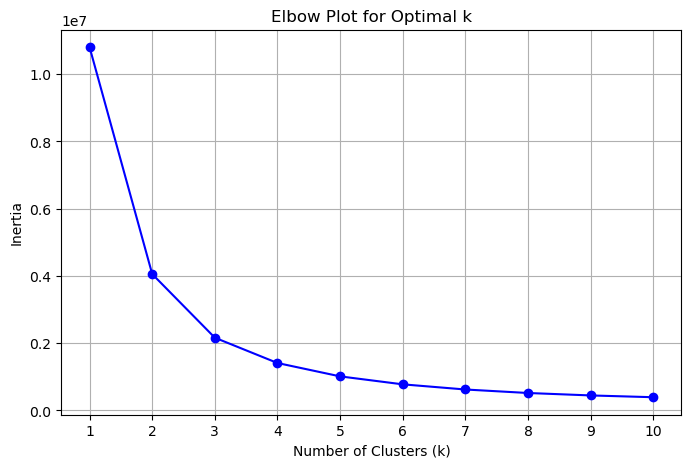

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('tracks.csv')

# Split the data
train_df, _ = train_test_split(df, test_size=0.3, random_state=42)
train_df = train_df[["danceability", "energy", "loudness", "speechiness", 
                     "acousticness", "instrumentalness", "liveness", "valence"]]

# Define the range of clusters to test
cluster_range = range(1, 11)
inertia_values = []

# Compute inertia for each number of clusters
for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(train_df)
    inertia_values.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertia_values, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Plot for Optimal k')
plt.xticks(cluster_range)
plt.grid(True)

In [1]:
pip install tqdm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Computing K-Means: 100%|██████████| 10/10 [01:29<00:00,  8.99s/it]


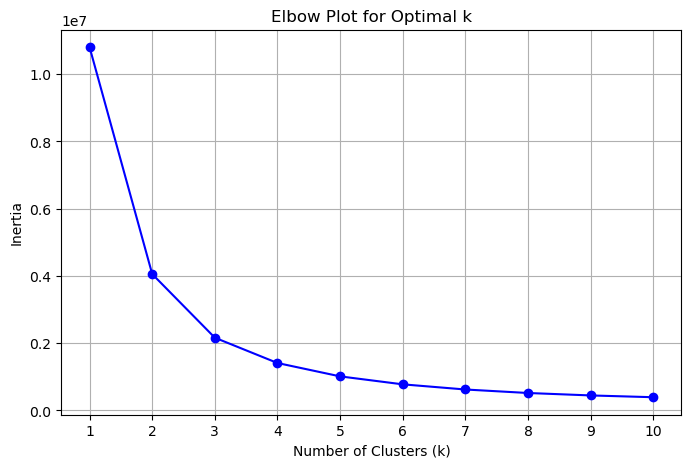

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load the dataset
df = pd.read_csv('tracks.csv')

# Split the data
train_df, _ = train_test_split(df, test_size=0.3, random_state=42)
train_df = train_df[["danceability", "energy", "loudness", "speechiness", 
                     "acousticness", "instrumentalness", "liveness", "valence"]]

# Optional: Sample a smaller subset for testing
# train_df = train_df.sample(frac=0.1, random_state=42)

# Define the range of clusters to test
cluster_range = range(1, 11)
inertia_values = []

# Compute inertia for each number of clusters
for n_clusters in tqdm(cluster_range, desc="Computing K-Means"):
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
    kmeans.fit(train_df)
    inertia_values.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertia_values, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Plot for Optimal k')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load the dataset
df = pd.read_csv('tracks.csv')

# Split the data
train_df, _ = train_test_split(df, test_size=0.3, random_state=42)
train_df = train_df[["danceability", "energy", "loudness", "speechiness", 
                     "acousticness", "instrumentalness", "liveness", "valence"]]

# Optional: Sample a smaller subset for testing
# train_df = train_df.sample(frac=0.1, random_state=42)

# Define the range of clusters to test
cluster_range = range(2, 11)  # Silhouette score is not defined for k=1
silhouette_scores = []

# Compute silhouette score for each number of clusters
for n_clusters in tqdm(cluster_range, desc="Computing Silhouette Scores"):
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
    cluster_labels = kmeans.fit_predict(train_df)
    silhouette_avg = silhouette_score(train_df, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot the silhouette score graph
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, silhouette_scores, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

Computing Silhouette Scores:   0%|          | 0/9 [00:00<?, ?it/s]

<AxesSubplot:xlabel='loudness', ylabel='liveness'>

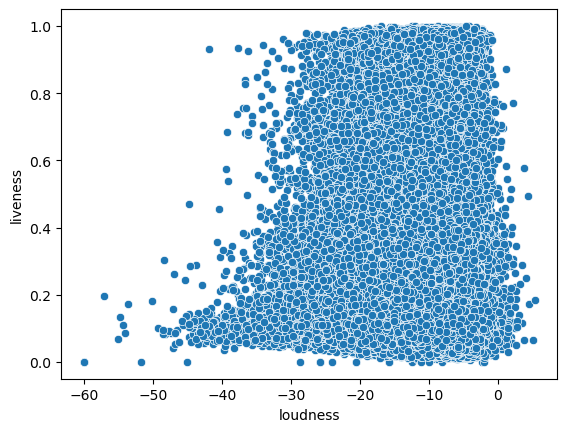

In [2]:
import seaborn as sns
import pandas as pd
df = pd.read_csv('tracks.csv')

sns.scatterplot(data=df, x="loudness", y="liveness")


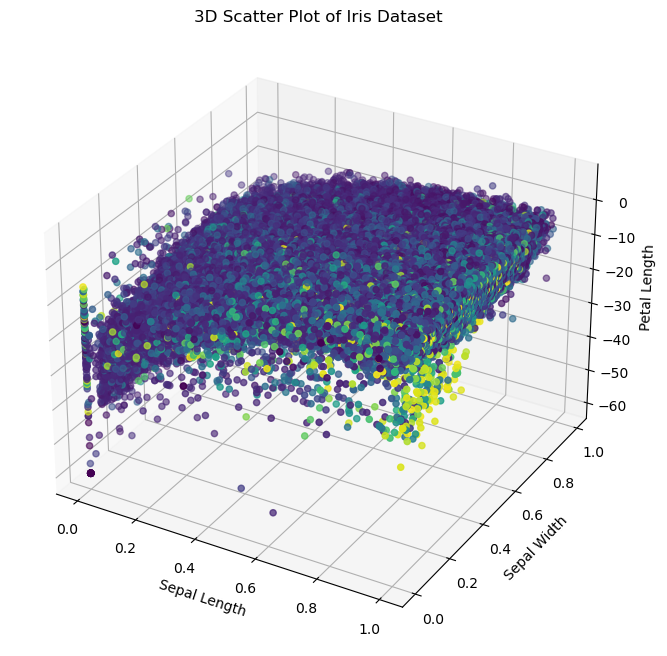

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import pandas as pd

# Load a sample dataset (replace with your data)

# Create the 3D figure and axes
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(df['energy'], df['danceability'], df['loudness'], c=df['liveness'], cmap='viridis', marker='o')

# Set labels
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')

# Add title
ax.set_title('3D Scatter Plot of Iris Dataset')

# Show the plot
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
df = pd.read_csv('tracks.csv')

# Sample data
x = df["danceability"]
y = df["energy"]

# Calculate the point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# Create scatterplot with density hue
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x, y=y, hue=z, palette='viridis', legend=False)
plt.title("Scatterplot with Density Hue")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

In [3]:
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd
# Sample data
df = pd.read_csv('tracks.csv')
df2 = dfdrop(columns=["id.", "Price", "Open", "High", "Low"])
# DBSCAN clustering
dbscan = DBSCAN(eps=1, min_samples=2)
clusters = dbscan.fit_predict(df2)

# Print cluster labels
print(clusters)
# Output: [ 0  0 -1  1  0  1]
# -1 represents noise points

# Access cluster assignments for each data point
labels = dbscan.labels_

# Number of clusters, ignoring noise if present.
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f'Estimated number of clusters: {n_clusters}')

# Get the core samples
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

C:\Users\phowlett\AppData\Local\Temp\ipykernel_36224\2811736599.py:6: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  df2 = df.drop("id","name",'artists','id_artists','release_date')


ValueError: Cannot specify both 'labels' and 'index'/'columns'